In [1]:
# PROJECT: Customer Segmentation using SQL
# COMPANY: Nurogen Healthcare Ltd.
# METHOD:  RFM Analysis (Recency, Frequency, Monetary)
# TOOLS:   SQLite, Python, Pandas

# Imports

import sqlite3
# sqlite3 is built into Python — no installation needed.
# It lets us create and query a real SQL database.
# The entire database is stored as a single .db file
# on your computer — simple but genuinely powerful.

import pandas as pd
# We already know this — for reading CSV and displaying results

import numpy as np
# For numerical calculations

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# For visualising our segments at the end

import seaborn as sns
# For styled charts

import os
# For file paths

# Paths
# Where our CSV lives (from P1)
CSV_PATH = '../data/leads.csv'

# Where we'll save the database
DB_PATH  = '../data/nurogen_crm.db'

# Where charts go
CHARTS_PATH = '../charts/'
os.makedirs(CHARTS_PATH, exist_ok=True)

# ── Colours (same palette as P1 — consistent style) ────────
C_PURPLE = "#7F77DD"
C_TEAL   = "#1D9E75"
C_AMBER  = "#EF9F27"
C_CORAL  = "#D85A30"
C_GRAY   = "#888780"
C_GREEN  = "#3B6D11"
C_BLUE   = "#185FA5"

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

# Verify CSV exists from P1 
if os.path.exists(CSV_PATH):
    df_raw = pd.read_csv(CSV_PATH)
    print(" Libraries loaded successfully!")
    print(f" leads.csv found — {len(df_raw)} rows loaded")
    print(f"\n   Columns available:")
    for col in df_raw.columns:
        print(f"   → {col}")
else:
    print(" leads.csv not found!")
    print(f"   Expected location: {os.path.abspath(CSV_PATH)}")
    print(f"   Make sure you completed P1 first.")


 Libraries loaded successfully!
 leads.csv found — 250 rows loaded

   Columns available:
   → lead_id
   → company_name
   → sector
   → region
   → product_interest
   → lead_source
   → pipeline_stage
   → deal_size_gbp
   → follow_up_count
   → response_time_days
   → win_probability
   → created_date
   → outcome


In [2]:
# Create the database and tables

# Connect to the database 
conn = sqlite3.connect(DB_PATH)
# conn = "connection" — our open channel to the database
cursor = conn.cursor()

print("✅ Database connection opened")
print(f"   Location: {os.path.abspath(DB_PATH)}")

# Drop tables if they already exist 

cursor.execute("DROP TABLE IF EXISTS customers")
cursor.execute("DROP TABLE IF EXISTS deals")
cursor.execute("DROP TABLE IF EXISTS interactions")
# cursor.execute() sends one SQL command to the database

print(" Old tables cleared (if any existed)")

# Create the CUSTOMERS table 

cursor.execute("""
    CREATE TABLE customers (
        customer_id   TEXT PRIMARY KEY,
        company_name  TEXT NOT NULL,
        sector        TEXT,
        region        TEXT,
        lead_source   TEXT
    )
""")

print(" Table created: customers")

#  Create the DEALS table 
# This table stores WHAT each customer is buying.
# One row per lead/deal.

cursor.execute("""
    CREATE TABLE deals (
        deal_id         TEXT PRIMARY KEY,
        customer_id     TEXT,
        product         TEXT,
        deal_size_gbp   REAL,
        pipeline_stage  TEXT,
        win_probability INTEGER,
        outcome         INTEGER,
        created_date    TEXT,
        FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
    )
""")

print("✅ Table created: deals")

# Create the INTERACTIONS table 

cursor.execute("""
    CREATE TABLE interactions (
        interaction_id      TEXT PRIMARY KEY,
        customer_id         TEXT,
        follow_up_count     INTEGER,
        response_time_days  INTEGER,
        created_date        TEXT,
        FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
    )
""")

print("✅ Table created: interactions")

# Save (commit) the changes

conn.commit()

print("\n✅ All tables created and saved!")
print("\n   Database structure:")
print("   customers    → who we sell to")
print("   deals        → what they buy")
print("   interactions → how we engage them")


✅ Database connection opened
   Location: C:\Users\Sriha\OneDrive\Documents\GitHub\pharma-pipeline-analysis\data\nurogen_crm.db
 Old tables cleared (if any existed)
 Table created: customers
✅ Table created: deals
✅ Table created: interactions

✅ All tables created and saved!

   Database structure:
   customers    → who we sell to
   deals        → what they buy
   interactions → how we engage them


In [3]:
# Insert data from leads.csv into the database

# Read the CSV 
df = pd.read_csv(CSV_PATH)
df['created_date'] = pd.to_datetime(df['created_date'])
print(f"✅ CSV loaded: {len(df)} rows")

# Build the CUSTOMERS table data

customers_df = df[[
    'lead_id',        # → customer_id
    'company_name',
    'sector',
    'region',
    'lead_source'
]].copy()


# Rename lead_id to customer_id
customers_df = customers_df.rename(columns={'lead_id': 'customer_id'})

# Build the DEALS table data 
deals_df = df[[
    'lead_id',
    'product_interest',
    'deal_size_gbp',
    'pipeline_stage',
    'win_probability',
    'outcome',
    'created_date'
]].copy()

deals_df.insert(0, 'deal_id',
    deals_df['lead_id'].str.replace('NHC-', 'DEAL-'))

# Rename columns to match our table schema
deals_df = deals_df.rename(columns={
    'lead_id':         'customer_id',
    'product_interest':'product',
    'created_date':    'created_date'
})

# Format date as text for SQLite
deals_df['created_date'] = deals_df['created_date'].dt.strftime('%Y-%m-%d')

# Build the INTERACTIONS table data 
interactions_df = df[[
    'lead_id',
    'follow_up_count',
    'response_time_days',
    'created_date'
]].copy()

# Add interaction_id
interactions_df.insert(0, 'interaction_id',
    interactions_df['lead_id'].str.replace('NHC-', 'INT-'))

interactions_df = interactions_df.rename(columns={
    'lead_id': 'customer_id'
})
interactions_df['created_date'] = pd.to_datetime(
    interactions_df['created_date']).dt.strftime('%Y-%m-%d')

# Insert into database 

customers_df.to_sql(
    'customers',      # table name in database
    conn,             # our connection
    if_exists='append',
    index=False
)
print(f"✅ customers table: {len(customers_df)} rows inserted")

deals_df.to_sql('deals', conn, if_exists='append', index=False)
print(f"✅ deals table:     {len(deals_df)} rows inserted")

interactions_df.to_sql(
    'interactions', conn, if_exists='append', index=False)
print(f"✅ interactions table: {len(interactions_df)} rows inserted")

conn.commit()

# Verify with first SQL SELECT query 

print("\n── First 3 rows of customers table ──────────────")
result = pd.read_sql("SELECT * FROM customers LIMIT 3", conn)
print(result.to_string(index=False))

print("\n── First 3 rows of deals table ──────────────────")
result2 = pd.read_sql("SELECT * FROM deals LIMIT 3", conn)
print(result2.to_string(index=False))

print("\n✅ Database fully loaded and verified!")


✅ CSV loaded: 250 rows
✅ customers table: 250 rows inserted
✅ deals table:     250 rows inserted
✅ interactions table: 250 rows inserted

── First 3 rows of customers table ──────────────
customer_id          company_name                sector             region       lead_source
   NHC-1160 Vantage Life Sciences     Hospital Pharmacy           Scotland        Trade Show
   NHC-1212   Crest Life Sciences Retail Pharmacy Chain North West England       Distributor
   NHC-1164    Altum Therapeutics Retail Pharmacy Chain             London LinkedIn Outreach

── First 3 rows of deals table ──────────────────
  deal_id customer_id                     product  deal_size_gbp pipeline_stage  win_probability outcome created_date
DEAL-1160    NHC-1160  Oleochemicals / Lubricants         6900.0       Prospect               17    None   2023-08-05
DEAL-1212    NHC-1212 Organic Chemicals / Binders        19100.0    Negotiation               56    None   2023-08-06
DEAL-1164    NHC-1164  Oleochemical

In [4]:
# Core SQL queries — business questions

def run_query(sql, title=""):
    """
    Runs a SQL query and displays the result as a table.
    
    sql   = the SQL query string to run
    title = optional heading to print above the result
    """
    if title:
        print(f"\n{'─' * 55}")
        print(f"  {title}")
        print(f"{'─' * 55}")
    result = pd.read_sql(sql, conn)
    print(result.to_string(index=False))
    print(f"\n  → {len(result)} rows returned")
    return result
 

print("✅ Helper function defined — ready to query!")

✅ Helper function defined — ready to query!


In [5]:
# ============================================================
# CELL 4a: Basic SELECT queries (corrected)
# ============================================================

# ── QUERY 1: Look at customers table ──────────────────────
run_query("""
    SELECT *
    FROM customers
    LIMIT 5
""", "Query 1: First 5 customers")

# ── QUERY 2: Specific columns only ────────────────────────
run_query("""
    SELECT company_name,
           sector,
           region
    FROM customers
    LIMIT 5
""", "Query 2: Specific columns only")

# ── QUERY 3: WHERE filter ──────────────────────────────────
run_query("""
    SELECT company_name,
           sector,
           region
    FROM customers
    WHERE region = 'London'
    LIMIT 5
""", "Query 3: Only London customers")

# ── QUERY 4: WHERE with AND ───────────────────────────────
run_query("""
    SELECT company_name,
           sector,
           region
    FROM customers
    WHERE region = 'London'
    AND   sector = 'CDMO / Generic Manufacturer'
""", "Query 4: London CDMOs only")

# ── QUERY 5: Top 10 largest deals WITH company names ──────
# FIXED: company_name is in customers, deal data is in deals
# We JOIN both tables using the shared customer_id column
# c. prefix = column from customers table
# d. prefix = column from deals table
run_query("""
    SELECT c.company_name,
           c.sector,
           d.deal_size_gbp,
           d.pipeline_stage
    FROM deals d
    JOIN customers c
        ON d.customer_id = c.customer_id
    ORDER BY d.deal_size_gbp DESC
    LIMIT 10
""", "Query 5: Top 10 largest deals with company names")


───────────────────────────────────────────────────────
  Query 1: First 5 customers
───────────────────────────────────────────────────────
customer_id          company_name                         sector             region       lead_source
   NHC-1160 Vantage Life Sciences              Hospital Pharmacy           Scotland        Trade Show
   NHC-1212   Crest Life Sciences          Retail Pharmacy Chain North West England       Distributor
   NHC-1164    Altum Therapeutics          Retail Pharmacy Chain             London LinkedIn Outreach
   NHC-1224         Orbis API Ltd    CDMO / Generic Manufacturer South East England        Cold Email
   NHC-1196        Syntek Biotech Licensed Specials Manufacturer            Germany LinkedIn Outreach

  → 5 rows returned

───────────────────────────────────────────────────────
  Query 2: Specific columns only
───────────────────────────────────────────────────────
         company_name                         sector             region
Vantage

,company_name,sector,deal_size_gbp,pipeline_stage
0,Biopharma Sciences,CDMO / Generic Manufacturer,93500.0,Closed Won
1,Elara Healthcare,CDMO / Generic Manufacturer,92900.0,Negotiation
2,Pinnacle Formulations,CDMO / Generic Manufacturer,91800.0,Prospect
3,Forma Pharma,CDMO / Generic Manufacturer,91200.0,Negotiation
4,Orbis API Ltd,CDMO / Generic Manufacturer,90800.0,Closed Lost
5,Clarix Therapeutics,CDMO / Generic Manufacturer,82900.0,Quoted
6,Apex Therapeutics,CDMO / Generic Manufacturer,80900.0,Negotiation
7,Meridian Biotech,CDMO / Generic Manufacturer,80500.0,Negotiation
8,Solara Pharma,CDMO / Generic Manufacturer,80300.0,Negotiation
9,Vantage Labs,CDMO / Generic Manufacturer,80000.0,Quoted


In [6]:
# Aggregation queries

# Count leads per sector 
run_query("""
    SELECT sector,
           COUNT(*) AS total_leads
    FROM customers
    GROUP BY sector
    ORDER BY total_leads DESC
""", "Query 6: How many leads per sector?")

# Pipeline value per sector 
run_query("""
    SELECT c.sector,
           COUNT(*)                         AS total_leads,
           ROUND(SUM(d.deal_size_gbp))      AS total_pipeline_gbp,
           ROUND(AVG(d.deal_size_gbp))      AS avg_deal_gbp,
           ROUND(MAX(d.deal_size_gbp))      AS largest_deal_gbp,
           ROUND(MIN(d.deal_size_gbp))      AS smallest_deal_gbp
    FROM customers c
    JOIN deals d
        ON c.customer_id = d.customer_id
    GROUP BY c.sector
    ORDER BY total_pipeline_gbp DESC
""", "Query 7: Full pipeline breakdown per sector")

# Win rate per sector 
run_query("""
    SELECT c.sector,
           COUNT(*)  AS total_closed,

           SUM(CASE WHEN d.outcome = 1
                    THEN 1 ELSE 0 END)
               AS deals_won,

           SUM(CASE WHEN d.outcome = 0
                    THEN 1 ELSE 0 END)
               AS deals_lost,

           ROUND(
               AVG(CASE WHEN d.outcome = 1
                        THEN 1.0 ELSE 0 END) * 100
           ) AS win_rate_pct

    FROM customers c
    JOIN deals d
        ON c.customer_id = d.customer_id
    WHERE d.outcome IS NOT NULL
    GROUP BY c.sector
    ORDER BY win_rate_pct DESC
""", "Query 8: Win rate per sector")

# HAVING — filter after grouping 
run_query("""
    SELECT c.sector,
           COUNT(*)                     AS total_leads,
           ROUND(AVG(d.deal_size_gbp))  AS avg_deal_gbp,
           ROUND(SUM(d.deal_size_gbp))  AS total_pipeline_gbp
    FROM customers c
    JOIN deals d
        ON c.customer_id = d.customer_id
    GROUP BY c.sector
    HAVING COUNT(*) > 30
    ORDER BY avg_deal_gbp DESC
""", "Query 9: Only sectors with more than 30 leads")

# QUERY 10: Best lead sources by revenue won 
run_query("""
    SELECT c.lead_source,
           COUNT(*)                        AS total_won,
           ROUND(SUM(d.deal_size_gbp))     AS total_revenue_gbp,
           ROUND(AVG(d.deal_size_gbp))     AS avg_deal_gbp,
           ROUND(MAX(d.deal_size_gbp))     AS best_deal_gbp
    FROM customers c
    JOIN deals d
        ON c.customer_id = d.customer_id
    WHERE d.outcome = 1
    GROUP BY c.lead_source
    ORDER BY total_revenue_gbp DESC
""", "Query 10: Best lead sources by revenue won")

#  Three-table JOIN 
run_query("""
    SELECT c.company_name,
           c.sector,
           d.deal_size_gbp,
           d.pipeline_stage,
           i.follow_up_count,
           i.response_time_days
    FROM customers c
    JOIN deals d
        ON c.customer_id = d.customer_id
    JOIN interactions i
        ON c.customer_id = i.customer_id
    WHERE d.pipeline_stage = 'Closed Won'
    ORDER BY d.deal_size_gbp DESC
    LIMIT 10
""", "Query 11: Top 10 won deals — full picture")


───────────────────────────────────────────────────────
  Query 6: How many leads per sector?
───────────────────────────────────────────────────────
                        sector  total_leads
   CDMO / Generic Manufacturer           61
             Hospital Pharmacy           58
         Retail Pharmacy Chain           45
Licensed Specials Manufacturer           42
        Nutraceutical Producer           23
Contract Research Organisation           21

  → 6 rows returned

───────────────────────────────────────────────────────
  Query 7: Full pipeline breakdown per sector
───────────────────────────────────────────────────────
                        sector  total_leads  total_pipeline_gbp  avg_deal_gbp  largest_deal_gbp  smallest_deal_gbp
   CDMO / Generic Manufacturer           61           3348900.0       54900.0           93500.0            18500.0
Licensed Specials Manufacturer           42           1339800.0       31900.0           53500.0            15900.0
         Retail 

,company_name,sector,deal_size_gbp,pipeline_stage,follow_up_count,response_time_days
0,Biopharma Sciences,CDMO / Generic Manufacturer,93500.0,Closed Won,3,37
1,Centrix Sciences,CDMO / Generic Manufacturer,71500.0,Closed Won,5,43
2,Fortis Chemicals,Licensed Specials Manufacturer,41700.0,Closed Won,5,18
3,Syntek Labs,CDMO / Generic Manufacturer,40500.0,Closed Won,5,39
4,Orbis Therapeutics,Licensed Specials Manufacturer,37300.0,Closed Won,2,24
5,Forma Labs,Licensed Specials Manufacturer,36600.0,Closed Won,3,36
6,Helix Medical,CDMO / Generic Manufacturer,34300.0,Closed Won,3,41
7,Zenith Life Sciences,Nutraceutical Producer,25700.0,Closed Won,5,23
8,Lumex Medical,Retail Pharmacy Chain,24700.0,Closed Won,5,36
9,Praxis API Ltd,Retail Pharmacy Chain,24200.0,Closed Won,3,32


In [7]:
# RFM Scoring using CTEs and Window Functions

rfm_query = """
WITH base_metrics AS (
    -- ── STEP 1: Calculate raw R, F, M values ─────────────
    -- For each customer, calculate:
    -- R = how many days since their last interaction?
    --     fewer days = more recent = better
    -- F = how many follow-up interactions total?
    --     more = more engaged = better  
    -- M = what is their total deal value?
    --     higher = more valuable = better

    SELECT
        c.customer_id,
        c.company_name,
        c.sector,
        c.region,

        -- RECENCY: days since most recent interaction
        -- julianday() converts a date to a number
        -- julianday('now') = today as a number
        -- Subtracting gives us the difference in days
        -- MIN(created_date) gives us earliest date
        -- We use MAX to get MOST RECENT date
        ROUND(
            julianday('now') - julianday(MAX(i.created_date))
        ) AS days_since_last_contact,
        -- Lower number = more recent = better recency

        -- FREQUENCY: total follow-up interactions
        SUM(i.follow_up_count) AS total_interactions,
        -- Higher number = more engaged = better frequency

        -- MONETARY: total deal value across all deals
        ROUND(SUM(d.deal_size_gbp)) AS total_deal_value
        -- Higher value = more valuable = better monetary

    FROM customers c
    JOIN deals d
        ON c.customer_id = d.customer_id
    JOIN interactions i
        ON c.customer_id = i.customer_id
    GROUP BY
        c.customer_id,
        c.company_name,
        c.sector,
        c.region
    -- GROUP BY customer so we get one row per customer
    -- with their aggregated R, F, M values
),

rfm_scores AS (
    -- ── STEP 2: Convert raw values to 1-4 scores ─────────
    -- NTILE(4) splits all customers into 4 equal groups
    -- and assigns 1, 2, 3, or 4 to each group.
    --
    -- OVER (ORDER BY ...) tells NTILE how to rank customers
    -- before splitting into groups.
    --
    -- For RECENCY: ORDER BY days DESC
    -- because FEWER days = more recent = should score higher
    -- So we order descending — most days first gets score 1
    -- least days (most recent) gets score 4
    --
    -- For FREQUENCY and MONETARY: ORDER BY value ASC
    -- because HIGHER value = better = should score 4
    -- So we order ascending — lowest gets 1, highest gets 4

    SELECT
        customer_id,
        company_name,
        sector,
        region,
        days_since_last_contact,
        total_interactions,
        total_deal_value,

        -- R score: recent customers score 4, old ones score 1
        NTILE(4) OVER (
            ORDER BY days_since_last_contact DESC
        ) AS r_score,
        -- ORDER BY DESC means most days = rank 1 = score 1
        -- fewest days (most recent) = rank last = score 4
        -- This feels backwards but remember:
        -- NTILE assigns 1 to the FIRST rows in the ordering

        -- F score: high interactions score 4
        NTILE(4) OVER (
            ORDER BY total_interactions ASC
        ) AS f_score,
        -- ORDER BY ASC means lowest interactions = score 1
        -- highest interactions = score 4 ✓

        -- M score: high deal value scores 4
        NTILE(4) OVER (
            ORDER BY total_deal_value ASC
        ) AS m_score
        -- ORDER BY ASC means lowest value = score 1
        -- highest value = score 4 ✓

    FROM base_metrics
),

rfm_combined AS (
    -- ── STEP 3: Combine scores into one RFM number ────────
    -- We combine R, F, M into a 3-digit score string
    -- e.g. R=4, F=3, M=4 → "434"
    -- Then calculate total score (sum of all three)
    -- for easy ranking

    SELECT
        customer_id,
        company_name,
        sector,
        region,
        days_since_last_contact,
        total_interactions,
        total_deal_value,
        r_score,
        f_score,
        m_score,

        -- Combine into readable 3-digit code
        CAST(r_score AS TEXT) ||
        CAST(f_score AS TEXT) ||
        CAST(m_score AS TEXT) AS rfm_code,
        -- || is SQL string concatenation (joining text)
        -- CAST(4 AS TEXT) converts number 4 to text "4"
        -- So 4 || 3 || 4 = "434"

        -- Total score for ranking (max possible = 12)
        (r_score + f_score + m_score) AS rfm_total_score

    FROM rfm_scores
)

-- ── STEP 4: Add segment names and final output ────────────
-- Based on the RFM total score and individual scores,
-- we assign each customer to a named business segment.
-- CASE WHEN works like if/elif/else in Python.
-- SQL checks each WHEN in order and stops at first match.

SELECT
    customer_id,
    company_name,
    sector,
    region,
    days_since_last_contact,
    total_interactions,
    total_deal_value,
    r_score,
    f_score,
    m_score,
    rfm_code,
    rfm_total_score,

    CASE
        -- Champions: high on ALL three dimensions
        WHEN rfm_total_score >= 11
            THEN 'Champion'

        -- Loyal: high frequency and monetary
        WHEN f_score >= 3 AND m_score >= 3 AND r_score >= 2
            THEN 'Loyal Customer'

        -- Big Spenders: high monetary, lower frequency
        WHEN m_score = 4 AND f_score <= 2
            THEN 'Big Spender'

        -- Promising: recent but not yet high value
        WHEN r_score >= 3 AND rfm_total_score >= 7
            THEN 'Promising'

        -- At Risk: used to be good, going cold
        WHEN r_score <= 2 AND f_score >= 3 AND m_score >= 3
            THEN 'At Risk'

        -- Needs Attention: mid scores across the board
        WHEN rfm_total_score BETWEEN 6 AND 8
            THEN 'Needs Attention'

        -- Lost: low on everything
        WHEN rfm_total_score <= 5
            THEN 'Lost'

        -- Catch-all for anything not matched above
        ELSE 'Other'
    END AS customer_segment

FROM rfm_combined
ORDER BY rfm_total_score DESC
"""

#  Run the query 
print("Running RFM analysis...")
rfm_df = pd.read_sql(rfm_query, conn)
# We save result to rfm_df — we'll use it for charts next

print(f"✅ RFM scoring complete!")
print(f"   Total customers scored: {len(rfm_df)}")

# Show top 15 customers 
print("\n── Top 15 customers by RFM score ────────────────────")
top15 = rfm_df[[
    'company_name', 'sector',
    'r_score', 'f_score', 'm_score',
    'rfm_code', 'rfm_total_score',
    'customer_segment'
]].head(15)
print(top15.to_string(index=False))

# Segment distribution
print("\n── Customer segment breakdown ───────────────────────")
segment_counts = rfm_df['customer_segment'].value_counts()
total = len(rfm_df)
for segment, count in segment_counts.items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    print(f"   {segment:<20} {count:>3} customers  "
          f"{pct:>5.1f}%  {bar}")

#  Segment value summary 
print("\n── Average deal value per segment ───────────────────")
seg_value = rfm_df.groupby('customer_segment').agg(
    count=('customer_id', 'count'),
    avg_deal=('total_deal_value', 'mean'),
    total_value=('total_deal_value', 'sum')
).round(0).sort_values('avg_deal', ascending=False)

for seg, row in seg_value.iterrows():
    print(f"   {seg:<20} "
          f"avg: £{row['avg_deal']:>8,.0f}   "
          f"total: £{row['total_value']:>10,.0f}")


Running RFM analysis...
✅ RFM scoring complete!
   Total customers scored: 250

── Top 15 customers by RFM score ────────────────────
         company_name                         sector  r_score  f_score  m_score rfm_code  rfm_total_score customer_segment
     Vitagen Sciences    CDMO / Generic Manufacturer        4        4        4      444               12         Champion
     Centrix Sciences    CDMO / Generic Manufacturer        4        4        4      444               12         Champion
Kinara Nutraceuticals    CDMO / Generic Manufacturer        4        4        4      444               12         Champion
     Elara Healthcare    CDMO / Generic Manufacturer        4        4        4      444               12         Champion
    Apex Therapeutics    CDMO / Generic Manufacturer        3        4        4      344               11         Champion
     Meridian API Ltd    CDMO / Generic Manufacturer        3        4        4      344               11         Champion
     

In [8]:
# Save RFM results

rfm_path = '../data/rfm_segments.csv'
rfm_df.to_csv(rfm_path, index=False)

print(f"✅ RFM results saved!")
print(f"   Location : {os.path.abspath(rfm_path)}")
print(f"   Rows     : {len(rfm_df)}")
print(f"   Columns  : {list(rfm_df.columns)}")
print(f"\n   Open rfm_segments.csv in Excel to see")
print(f"   every customer with their RFM scores")
print(f"   and segment label.")

✅ RFM results saved!
   Location : C:\Users\Sriha\OneDrive\Documents\GitHub\pharma-pipeline-analysis\data\rfm_segments.csv
   Rows     : 250
   Columns  : ['customer_id', 'company_name', 'sector', 'region', 'days_since_last_contact', 'total_interactions', 'total_deal_value', 'r_score', 'f_score', 'm_score', 'rfm_code', 'rfm_total_score', 'customer_segment']

   Open rfm_segments.csv in Excel to see
   every customer with their RFM scores
   and segment label.


In [9]:
# Set up segment colours

segment_colours = {
    'Champion':        '#1D9E75',   # teal green — best customers
    'Loyal Customer':  '#3B6D11',   # dark green — reliable
    'Big Spender':     '#7F77DD',   # purple — high value
    'Promising':       '#185FA5',   # blue — future potential
    'Needs Attention': '#EF9F27',   # amber — caution
    'At Risk':         '#D85A30',   # coral — danger
    'Lost':            '#888780',   # gray — deprioritise
    'Other':           '#B4B2A9',   # light gray
}

segment_order = (
    rfm_df.groupby('customer_segment')['total_deal_value']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

print("✅ Segment colours defined")
print(f"\n   Segment order (by avg deal value):")
for i, seg in enumerate(segment_order, 1):
    print(f"   {i}. {seg}")

✅ Segment colours defined

   Segment order (by avg deal value):
   1. Champion
   2. Big Spender
   3. At Risk
   4. Loyal Customer
   5. Promising
   6. Needs Attention
   7. Lost


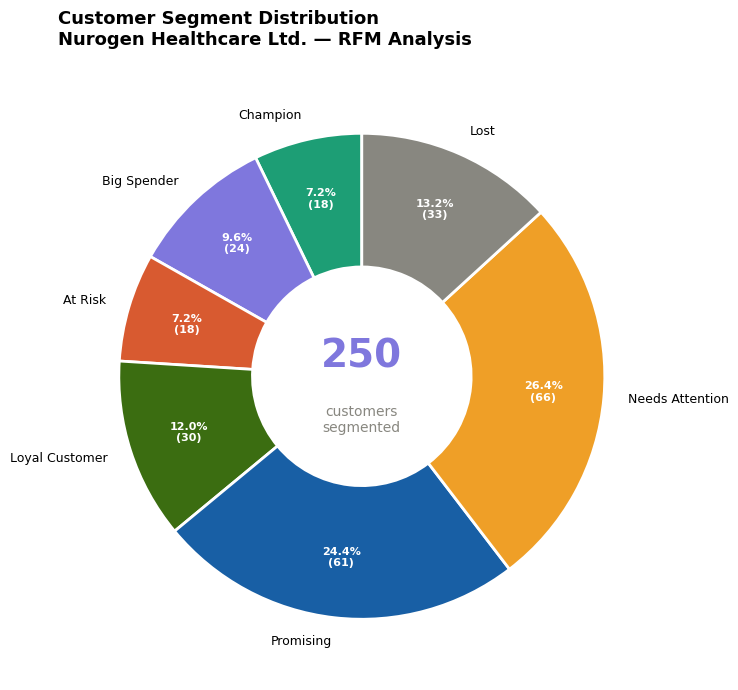

✅ Chart 5 saved!


In [10]:
# Chart 1 — Segment Distribution (Donut Chart)

# Prepare data 
seg_counts = rfm_df['customer_segment'].value_counts()
# Reorder to match our segment_order list
seg_counts = seg_counts.reindex(
    [s for s in segment_order if s in seg_counts.index]
)

colours = [segment_colours.get(s, C_GRAY) for s in seg_counts.index]
# List comprehension: for each segment name, get its colour
# .get(s, C_GRAY) returns C_GRAY if segment not in dict

# Build chart 
fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    seg_counts.values,          # slice sizes
    labels=seg_counts.index,    # segment names
    colors=colours,             # our colour palette
    autopct=lambda pct:         # percentage label inside slice
        f'{pct:.1f}%\n({int(round(pct/100*sum(seg_counts.values)))})',
    # lambda = a small anonymous function
    # pct = the percentage value matplotlib passes in
    # We show "XX.X%\n(N customers)" inside each slice
    pctdistance=0.75,           # how far from centre to put %
    startangle=90,              # start drawing from top
    wedgeprops=dict(
        width=0.55,             # donut hole size (1=full pie, 0=no chart)
        edgecolor='white',      # white lines between slices
        linewidth=2
    )
)

# Style the percentage labels inside slices
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Style the segment name labels outside slices
for text in texts:
    text.set_fontsize(9)

# Add centre text inside the donut hole
ax.text(
    0, 0.08,                    # x=0, y=slightly above centre
    str(len(rfm_df)),           # total customer count
    ha='center', va='center',
    fontsize=28,
    fontweight='bold',
    color=C_PURPLE
)
ax.text(
    0, -0.18,                   # x=0, y=slightly below centre
    'customers\nsegmented',
    ha='center', va='center',
    fontsize=10,
    color=C_GRAY
)

ax.set_title(
    'Customer Segment Distribution\n'
    'Nurogen Healthcare Ltd. — RFM Analysis',
    fontsize=13,
    fontweight='bold',
    pad=20,
    loc='left'
)

plt.tight_layout()
chart5_path = CHARTS_PATH + 'chart5_segment_distribution.png'
plt.savefig(chart5_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart 5 saved!")

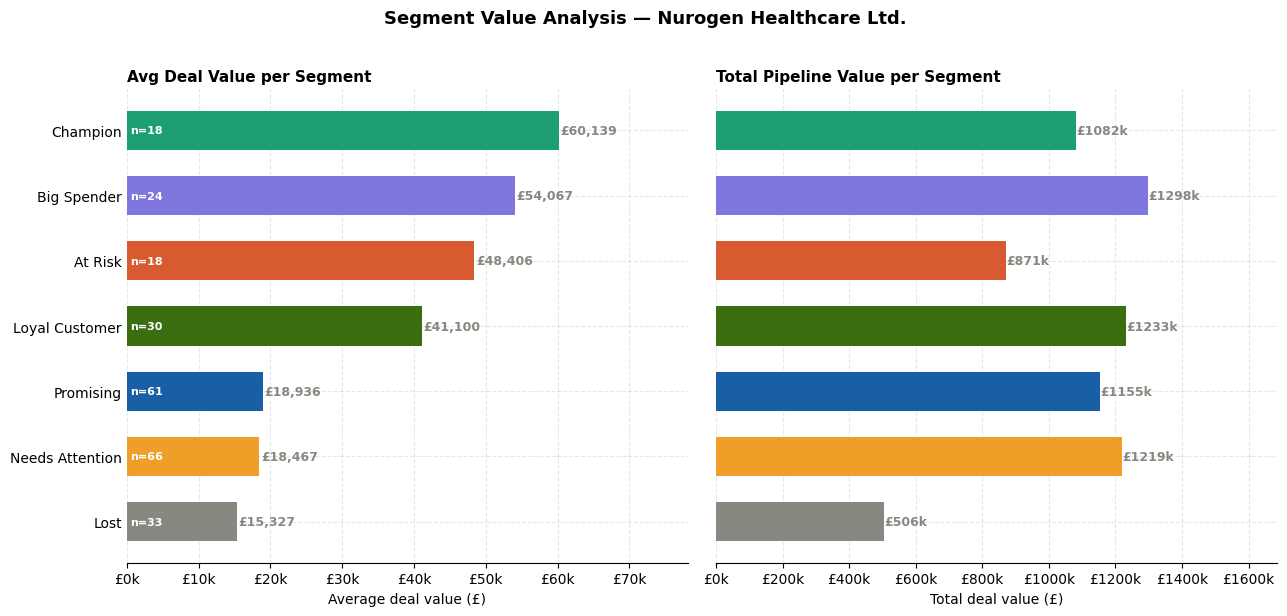

✅ Chart 6 saved!


In [11]:
# Chart 2 — Segment Value Comparison

# ── Prepare data ───────────────────────────────────────────
seg_stats = rfm_df.groupby('customer_segment').agg(
    count=       ('customer_id',    'count'),
    avg_value=   ('total_deal_value','mean'),
    total_value= ('total_deal_value','sum'),
    avg_r=       ('r_score',        'mean'),
    avg_f=       ('f_score',        'mean'),
    avg_m=       ('m_score',        'mean')
).round(1)

# Reorder by avg_value descending
seg_stats = seg_stats.sort_values('avg_value', ascending=True)
# ascending=True because horizontal bars read bottom to top
# so the best segment ends up at the top

colours_ordered = [
    segment_colours.get(s, C_GRAY)
    for s in seg_stats.index
]

# ── Build chart ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

# ── LEFT: Average deal value ───────────────────────────────
bars1 = ax1.barh(
    seg_stats.index,
    seg_stats['avg_value'],
    color=colours_ordered,
    edgecolor='none',
    height=0.6
)

# Value labels at end of each bar
for bar, val in zip(bars1, seg_stats['avg_value']):
    ax1.text(
        val + 200,
        bar.get_y() + bar.get_height() / 2,
        f'£{val:,.0f}',
        va='center', fontsize=9,
        fontweight='bold', color=C_GRAY
    )

# Customer count inside each bar
for bar, (seg, row) in zip(bars1, seg_stats.iterrows()):
    ax1.text(
        500,                                  # near left edge
        bar.get_y() + bar.get_height() / 2,
        f'n={int(row["count"])}',
        va='center', ha='left',
        fontsize=8, color='white',
        fontweight='bold'
    )

ax1.set_xlabel('Average deal value (£)', fontsize=10)
ax1.set_title('Avg Deal Value per Segment',
              fontsize=11, fontweight='bold', loc='left')
ax1.set_xlim(0, seg_stats['avg_value'].max() * 1.3)
ax1.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax1.tick_params(axis='y', length=0)
ax1.spines['left'].set_visible(False)
ax1.xaxis.grid(True, alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# ── RIGHT: Total value ─────────────────────────────────────
bars2 = ax2.barh(
    seg_stats.index,
    seg_stats['total_value'],
    color=colours_ordered,
    edgecolor='none',
    height=0.6
)

for bar, val in zip(bars2, seg_stats['total_value']):
    ax2.text(
        val + 500,
        bar.get_y() + bar.get_height() / 2,
        f'£{val/1000:.0f}k',
        va='center', fontsize=9,
        fontweight='bold', color=C_GRAY
    )

ax2.set_xlabel('Total deal value (£)', fontsize=10)
ax2.set_title('Total Pipeline Value per Segment',
              fontsize=11, fontweight='bold', loc='left')
ax2.set_xlim(0, seg_stats['total_value'].max() * 1.3)
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax2.tick_params(axis='y', length=0)
ax2.spines['left'].set_visible(False)
ax2.xaxis.grid(True, alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

fig.suptitle(
    'Segment Value Analysis — Nurogen Healthcare Ltd.',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
chart6_path = CHARTS_PATH + 'chart6_segment_value.png'
plt.savefig(chart6_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart 6 saved!")

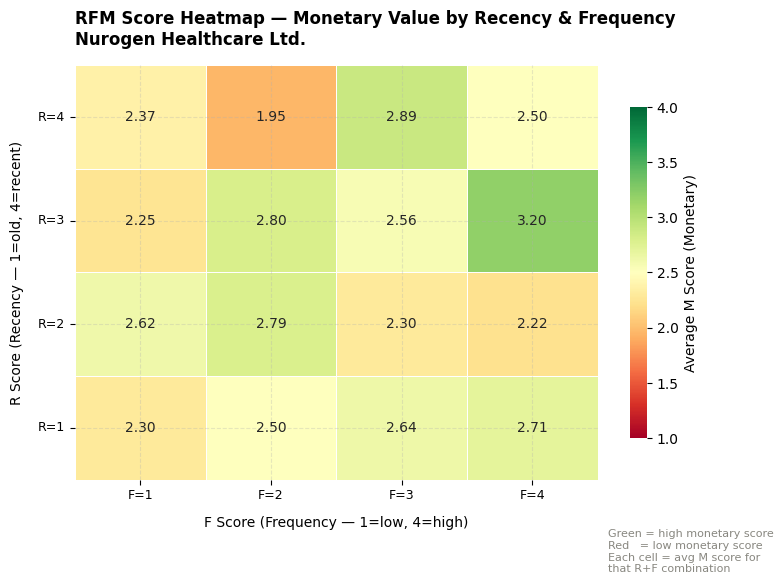

✅ Chart 7 saved!


In [12]:
# Chart 3 — RFM Score Heatmap

# Prepare pivot table 
rfm_pivot = rfm_df.pivot_table(
    values='m_score',        # what to show in the cells
    index='r_score',         # rows
    columns='f_score',       # columns
    aggfunc='mean'           # how to combine multiple values
).round(2)
# pivot_table() = SQL GROUP BY in two dimensions at once

# Sort so score 4 appears at top (best at top = intuitive)
rfm_pivot = rfm_pivot.sort_index(ascending=False)

# Build heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    rfm_pivot,
    annot=True,              # show values inside each cell
    fmt='.2f',               # format: 2 decimal places
    cmap='RdYlGn',           # colour map: Red=low, Yellow=mid, Green=high
    vmin=1, vmax=4,          # colour scale: 1=red, 4=green
    linewidths=0.5,          # thin lines between cells
    linecolor='white',       # white grid lines
    ax=ax,
    cbar_kws={
        'label': 'Average M Score (Monetary)',
        'shrink': 0.8
    }
)

# Axis labels
ax.set_xlabel('F Score (Frequency — 1=low, 4=high)',
              fontsize=10, labelpad=10)
ax.set_ylabel('R Score (Recency — 1=old, 4=recent)',
              fontsize=10, labelpad=10)

# Rotate tick labels for readability
ax.set_xticklabels(
    [f'F={int(float(t.get_text()))}' for t in ax.get_xticklabels()],
    rotation=0, fontsize=9
)
ax.set_yticklabels(
    [f'R={int(float(t.get_text()))}' for t in ax.get_yticklabels()],
    rotation=0, fontsize=9
)

ax.set_title(
    'RFM Score Heatmap — Monetary Value by Recency & Frequency\n'
    'Nurogen Healthcare Ltd.',
    fontsize=12, fontweight='bold',
    pad=15, loc='left'
)

# Add explanation annotation
ax.text(
    1.02, -0.12,
    'Green = high monetary score\n'
    'Red   = low monetary score\n'
    'Each cell = avg M score for\n'
    'that R+F combination',
    transform=ax.transAxes,
    fontsize=8, color=C_GRAY,
    verticalalignment='top'
)

plt.tight_layout()
chart7_path = CHARTS_PATH + 'chart7_rfm_heatmap.png'
plt.savefig(chart7_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart 7 saved!")

In [13]:
# Calculate all metrics for the report

# Segment summary
seg_summary = rfm_df.groupby('customer_segment').agg(
    count=       ('customer_id',     'count'),
    avg_value=   ('total_deal_value','mean'),
    total_value= ('total_deal_value','sum')
).round(0).sort_values('avg_value', ascending=False)

# Key numbers 
total_customers   = len(rfm_df)

# Champions
champions         = rfm_df[
    rfm_df['customer_segment'] == 'Champion']
champion_count    = len(champions)
champion_pct      = champion_count / total_customers * 100
champion_value    = champions['total_deal_value'].sum()

# At Risk
at_risk           = rfm_df[
    rfm_df['customer_segment'] == 'At Risk']
at_risk_count     = len(at_risk)
at_risk_value     = at_risk['total_deal_value'].sum()

# Lost
lost_seg          = rfm_df[
    rfm_df['customer_segment'] == 'Lost']
lost_count        = len(lost_seg)

# Promising
promising         = rfm_df[
    rfm_df['customer_segment'] == 'Promising']
promising_count   = len(promising)

# Best sector among champions
if champion_count > 0:
    best_champion_sector = (
        champions['sector']
        .value_counts()
        .idxmax()
    )
else:
    best_champion_sector = "N/A"

# Average RFM scores overall
avg_r = rfm_df['r_score'].mean()
avg_f = rfm_df['f_score'].mean()
avg_m = rfm_df['m_score'].mean()

# Highest value segment
highest_seg = seg_summary.index[0]
highest_avg = seg_summary['avg_value'].iloc[0]

# Total pipeline value across all segments
total_pipeline = rfm_df['total_deal_value'].sum()

print("=" * 55)
print("  REPORT METRICS VERIFIED")
print("=" * 55)
print(f"  Total customers      : {total_customers}")
print(f"  Champions            : {champion_count} ({champion_pct:.1f}%)")
print(f"  Champion value       : £{champion_value:,.0f}")
print(f"  At Risk              : {at_risk_count}")
print(f"  At Risk value        : £{at_risk_value:,.0f}")
print(f"  Lost                 : {lost_count}")
print(f"  Promising            : {promising_count}")
print(f"  Best champion sector : {best_champion_sector}")
print(f"  Avg R score          : {avg_r:.2f}")
print(f"  Avg F score          : {avg_f:.2f}")
print(f"  Avg M score          : {avg_m:.2f}")
print(f"  Highest value seg    : {highest_seg} (£{highest_avg:,.0f} avg)")
print(f"  Total pipeline value : £{total_pipeline:,.0f}")

  REPORT METRICS VERIFIED
  Total customers      : 250
  Champions            : 18 (7.2%)
  Champion value       : £1,082,500
  At Risk              : 18
  At Risk value        : £871,300
  Lost                 : 33
  Promising            : 61
  Best champion sector : CDMO / Generic Manufacturer
  Avg R score          : 2.49
  Avg F score          : 2.49
  Avg M score          : 2.49
  Highest value seg    : Champion (£60,139 avg)
  Total pipeline value : £7,364,100


In [14]:
# Write insight report

report = f"""# Customer Segmentation Analysis — RFM Model
## Nurogen Healthcare Ltd.

**Author:** Sri Harsha Gorantla
**Method:** RFM Analysis (Recency, Frequency, Monetary)
**Tools:** Python, SQLite, Pandas, Matplotlib, Seaborn
**Dataset:** {total_customers} customers from pharma excipient pipeline

## What is RFM Segmentation?

RFM is an industry-standard customer segmentation method
used across pharma, retail, finance and SaaS companies.
Every customer is scored 1–4 on three dimensions:

| Dimension | What it measures | Score 4 = |
|---|---|---|
| Recency (R) | How recently did they engage? | Very recent |
| Frequency (F) | How many interactions? | Highly engaged |
| Monetary (M) | How much are they worth? | High deal value |

Combined scores classify each customer into a named segment
that drives specific BD and account management actions.

---

## Segment Overview

| Segment | Customers | % of Total | Avg Deal Value |
|---|---|---|---|
{chr(10).join(
    f"| {seg} | {int(row['count'])} | "
    f"{row['count']/total_customers*100:.1f}% | "
    f"£{row['avg_value']:,.0f} |"
    for seg, row in seg_summary.iterrows()
)}

**Total pipeline value across all segments:**
£{total_pipeline:,.0f}

---

## Finding 1 — Champions ({champion_count} customers,
{champion_pct:.1f}% of base)

Champions score 4 on all three RFM dimensions —
they are the most recent, most engaged, and highest
value customers in the pipeline.

**Champion pipeline value:** £{champion_value:,.0f}

**Dominant sector:** {best_champion_sector}

These customers require white-glove account management.
They should never be left without contact for more than
30 days. Priority actions:

- Assign dedicated account manager
- Offer early access to new product lines
- Request referrals and testimonials
- Invite to product development feedback sessions

---

## Finding 2 — At Risk Customers ({at_risk_count} customers)

At Risk customers were previously high value but their
recency score has dropped — they are going cold.

**At Risk pipeline value:** £{at_risk_value:,.0f}

This represents revenue that is actively being lost.
Without intervention, At Risk customers typically
convert to Lost within 60–90 days.

**Recommended re-engagement actions:**
- Personal outreach from senior BD within 2 weeks
- Offer a pricing review or loyalty discount
- Share new product availability relevant to their sector
- Invite to site visit or technical consultation

**Priority:** Urgent — time-sensitive revenue recovery.

---

## Finding 3 — Promising Customers ({promising_count} customers)

Promising customers are recent and engaged but have
not yet reached high monetary scores. These represent
the highest growth potential in the pipeline.

**Recommended nurture actions:**
- Increase contact frequency to 2x per month
- Send targeted product samples or technical data sheets
- Introduce to Film Coating Excipients as upsell
- Invite to webinars or industry events

---

## Finding 4 — RFM Score Patterns

**Overall average scores:**

| Dimension | Average Score | Interpretation |
|---|---|---|
| Recency | {avg_r:.2f} / 4.00 | {'Strong' if avg_r >= 2.5 else 'Needs improvement'} |
| Frequency | {avg_f:.2f} / 4.00 | {'Strong' if avg_f >= 2.5 else 'Needs improvement'} |
| Monetary | {avg_m:.2f} / 4.00 | {'Strong' if avg_m >= 2.5 else 'Needs improvement'} |

The heatmap reveals that high Recency (R=4) customers
tend to have higher Monetary scores regardless of
Frequency — suggesting that recently re-engaged
customers quickly become higher spenders.

This supports prioritising re-engagement campaigns
over pure volume prospecting.

---

## Strategic Recommendations

| Priority | Segment | Action | Expected Outcome |
|---|---|---|---|
| 🔴 Urgent | At Risk | Personal senior outreach | Recover £{at_risk_value:,.0f} pipeline |
| 🔴 High | Champion | Dedicate account manager | Protect £{champion_value:,.0f} revenue |
| 🟡 Medium | Promising | Increase contact frequency | Convert to Loyal/Champion |
| 🟡 Medium | Needs Attention | Targeted email campaign | Re-activate engagement |
| 🟢 Low | Lost | Quarterly check-in only | Minimal BD resource |

---

## Technical Approach

**Database:** SQLite (3 normalised tables —
customers, deals, interactions)

**SQL techniques used:**
- Multi-table JOINs (2 and 3 table)
- Aggregate functions (COUNT, SUM, AVG)
- CASE WHEN conditional logic
- Common Table Expressions (CTEs)
- NTILE() window function for score banding
- IS NOT NULL filtering
- HAVING clause for group filtering

**Segmentation logic:**
Each customer scored 1–4 per dimension using NTILE(4).
Segments assigned via nested CASE WHEN on combined scores.

---

## Project Files
```
pharma-pipeline-analysis/
├── data/
│   ├── leads.csv              ← source data (from P1)
│   └── rfm_segments.csv       ← RFM scored customers
├── charts/
│   ├── chart5_segment_distribution.png
│   ├── chart6_segment_value.png
│   └── chart7_rfm_heatmap.png
└── notebooks/
    └── 02_customer_segmentation_sql.ipynb
```

---

*This project demonstrates SQL database design,
multi-table querying, window functions, and RFM
segmentation — applied to real pharma BD experience
from 14 months at Nurogen Healthcare Ltd.*
"""

# Save report 
report_path = '../README_p3_segmentation.md'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

print(f"✅ Report saved!")
print(f"   Location: {os.path.abspath(report_path)}")
print(f"   Lines   : {len(report.splitlines())}")

✅ Report saved!
   Location: C:\Users\Sriha\OneDrive\Documents\GitHub\pharma-pipeline-analysis\README_p3_segmentation.md
   Lines   : 171
